In [1]:
import os
import shutil
from pathlib import Path

# Create main folder
project_path = Path("./SplitDATA")
project_path.mkdir(exist_ok=True)

# Creating subfolders
folders = [
    "data/train/0", "data/train/1", "data/train/2", "data/train/3", "data/train/4",
    "data/val/0", "data/val/1", "data/val/2", "data/val/3", "data/val/4",
    "data/test/0", "data/test/1", "data/test/2", "data/test/3", "data/test/4",
    "checkpoints",
    "logs"
]

for folder in folders:
    (project_path / folder).mkdir(parents=True, exist_ok=True)
    print(f"✓ Created: {folder}")

✓ Created: data/train/0
✓ Created: data/train/1
✓ Created: data/train/2
✓ Created: data/train/3
✓ Created: data/train/4
✓ Created: data/val/0
✓ Created: data/val/1
✓ Created: data/val/2
✓ Created: data/val/3
✓ Created: data/val/4
✓ Created: data/test/0
✓ Created: data/test/1
✓ Created: data/test/2
✓ Created: data/test/3
✓ Created: data/test/4
✓ Created: checkpoints
✓ Created: logs


In [2]:

import pandas as pd
# Read the labels CSV: image_name, DR_level (0, 1, 2, 3, or 4)
try:
	labels_df = pd.read_csv("trainLabels.csv/trainLabels.csv")
except PermissionError as e:
	print(f"PermissionError: {e}. Error file 'trainLabels.csv!! ")
	labels_df = pd.DataFrame()
print("First 10 rows:")
print(labels_df.head(10))

print(f"\nTotal images: {len(labels_df)}")

# Count how many of each class
print("\nClass distribution:")
print(labels_df['level'].value_counts().sort_index())

First 10 rows:
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
5  15_right      2
6   16_left      4
7  16_right      4
8   17_left      0
9  17_right      1

Total images: 35126

Class distribution:
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


In [6]:
#arranging the data into train, val and test sets
import shutil
import random
import pandas as pd
from pathlib import Path

# forLoad labels
labels_df = pd.read_csv("trainLabels.csv/trainLabels.csv")

# for Base paths
images_raw_path = Path("train_images_compressed")
data_path = Path("SplitDATA/data")

# random seed for reproducibility
random.seed(42)

# Group images by class
for class_level in range(5):  
    ### 0, 1, 2, 3, 4
    class_images = labels_df[labels_df['level'] == class_level]['image'].values
    class_images = list(class_images)
    
    random.shuffle(class_images)
    
    # Calculate split
    total = len(class_images)
    train_size = int(total * 0.6)  # 60%
    val_size = int(total * 0.2)    # 20%
    
    train_imgs = class_images[:train_size]
    val_imgs = class_images[train_size:train_size + val_size]
    test_imgs = class_images[train_size + val_size:]
    
    print(f"\nClass {class_level}:")
    print(f"  Total: {total}")
    print(f"  Train: {len(train_imgs)} (60%)")
    print(f"  Val:   {len(val_imgs)} (20%)")
    print(f"  Test:  {len(test_imgs)} (20%)")
    
    # Copying train images
    for img_name in train_imgs:
        src = images_raw_path / f"{img_name}.jpg"
        dst = data_path / "train" / str(class_level) / f"{img_name}.jpg"
        
        if src.exists():
            shutil.copy2(src, dst)
    
    # Copying val images
    for img_name in val_imgs:
        src = images_raw_path / f"{img_name}.jpg"
        dst = data_path / "val" / str(class_level) / f"{img_name}.jpg"
        
        if src.exists():
            shutil.copy2(src, dst)
    
    # Copying test images
    for img_name in test_imgs:
        src = images_raw_path / f"{img_name}.jpg"
        dst = data_path / "test" / str(class_level) / f"{img_name}.jpg"
        
        if src.exists():
            shutil.copy2(src, dst)

print("\nImages organized!")


Class 0:
  Total: 25810
  Train: 15486 (60%)
  Val:   5162 (20%)
  Test:  5162 (20%)

Class 1:
  Total: 2443
  Train: 1465 (60%)
  Val:   488 (20%)
  Test:  490 (20%)

Class 2:
  Total: 5292
  Train: 3175 (60%)
  Val:   1058 (20%)
  Test:  1059 (20%)

Class 3:
  Total: 873
  Train: 523 (60%)
  Val:   174 (20%)
  Test:  176 (20%)

Class 4:
  Total: 708
  Train: 424 (60%)
  Val:   141 (20%)
  Test:  143 (20%)

Images organized!


In [13]:
# to verify Data Organization
from pathlib import Path
data_path = Path("SplitDATA/data")
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

print("Base path exists:", data_path.exists())
print("Base path:", data_path)

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} Set:")
    total_split = 0

    split_path = data_path / split
    print(f"  Split path exists: {split_path.exists()} -> {split_path}")

    for class_level in range(5):
        class_dir = split_path / str(class_level)

        if not class_dir.exists():
            num_images = 0
        else:
            num_images = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.jpeg"))) + len(list(class_dir.glob("*.png")))

        total_split += num_images
        print(f"  Class {class_level} ({class_names[class_level]:17s}): {num_images:5d} images")

    print(f"  {'-' * 40}")
    print(f"  Total {split}: {total_split} images")

##print("\nOverall verification complete!")

Base path exists: True
Base path: SplitDATA/data

TRAIN Set:
  Split path exists: True -> SplitDATA/data/train
  Class 0 (No DR            ): 15486 images
  Class 1 (Mild             ):  1465 images
  Class 2 (Moderate         ):  3175 images
  Class 3 (Severe           ):   523 images
  Class 4 (Proliferative DR ):   424 images
  ----------------------------------------
  Total train: 21073 images

VAL Set:
  Split path exists: True -> SplitDATA/data/val
  Class 0 (No DR            ):  5162 images
  Class 1 (Mild             ):   488 images
  Class 2 (Moderate         ):  1058 images
  Class 3 (Severe           ):   174 images
  Class 4 (Proliferative DR ):   141 images
  ----------------------------------------
  Total val: 7023 images

TEST Set:
  Split path exists: True -> SplitDATA/data/test
  Class 0 (No DR            ):  5162 images
  Class 1 (Mild             ):   490 images
  Class 2 (Moderate         ):  1059 images
  Class 3 (Severe           ):   176 images
  Class 4 (Proli

In [1]:

%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.3/341.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 4.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 37.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 19.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 24.7 MB/s eta 0:00:00:00:0100:01
  

In [2]:
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.1 MB/s eta 0:00:00:00:010:01


In [5]:
!pip install timm

In [6]:
!pip install scikit-learn

In [7]:
import sys
print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/.venv/bin/python


In [8]:
# Test all packages
from PIL import Image
import torch
import torchvision
import timm
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
print("All packages imported successfully!")

/user/HS402/sm04533/Downloads/AMLv2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All packages imported successfully!


In [9]:
# to create Data Loader
import os
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(5):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

# Train augmentation + preprocessing
train_transform = transforms.Compose([
    #transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation / test preprocessing only
val_test_transform = transforms.Compose([
    #transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

base_data = Path("SplitDATA") / "data"

train_dataset = DRDataset(base_data / "train", transform=train_transform)
val_dataset = DRDataset(base_data / "val", transform=val_test_transform)
test_dataset = DRDataset(base_data / "test", transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("\nData loader done!")

Train dataset: 21073 images
Val dataset:   7023 images
Test dataset:  7030 images

Data loader done!


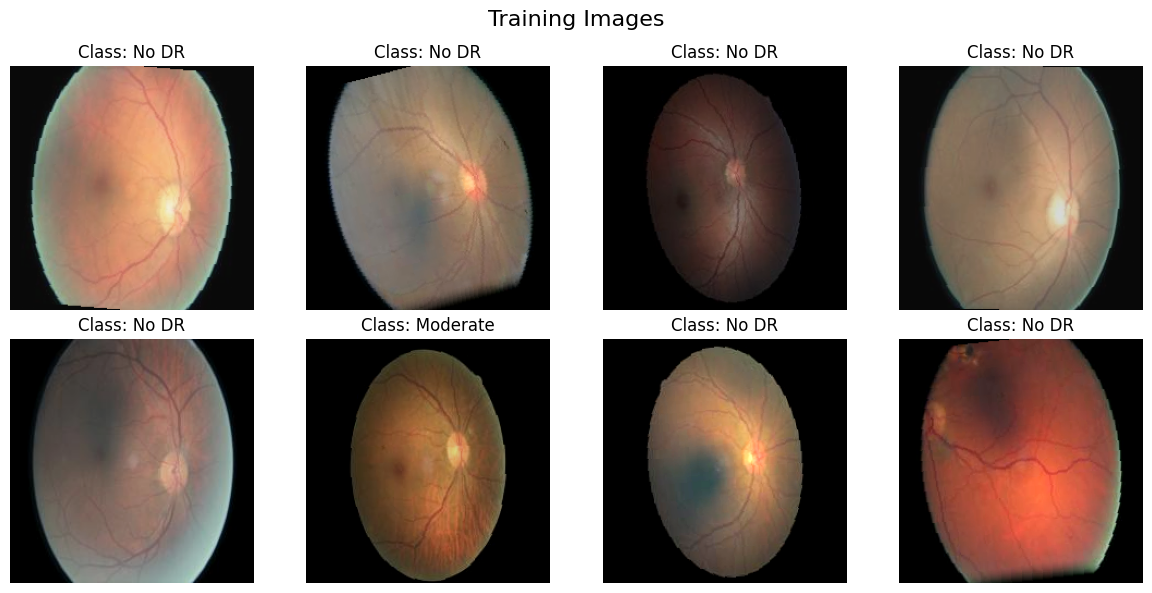

In [14]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [15]:
# creating DeiT Model
import torch
import torch.nn as nn
import timm

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Load DeiT-Small model
print("\nDeiT-model...")
model = timm.create_model(
    'deit_small_patch16_224',  # DeiT model
    pretrained=True,            # Pre-trained on ImageNet
    num_classes=5               # 5 DR severity levels
)

# Move to device
model = model.to(device)
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model loaded!")
print(f"  Total parameters: {total_params/1e6:.2f}M")
print(f"  Trainable parameters: {trainable_params/1e6:.2f}M")
# print(f"  Model architecture: DeiT-Small")
# print(f"  Patch size: 16×16")
# print(f"  Input size: 224×224")

Using device: cpu

DeiT-model...

✓ Model loaded!
  Total parameters: 21.67M
  Trainable parameters: 21.67M


In [16]:
#  Setup  Training Components
import torch.optim as optim

# Loss function (for classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam is a popular choice)
optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,          # Learning rate (small for fine-tuning)
    weight_decay=1e-4 # Regularization
)

# Learning rate scheduler (reduces LR over time)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=12,      # Total epochs
    eta_min=1e-6
)

print("✓ Training components ready!")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: AdamW")
print(f"  Learning rate: 5e-5")
print(f"  Scheduler: CosineAnnealing")

✓ Training components ready!
  Loss function: CrossEntropyLoss
  Optimizer: AdamW
  Learning rate: 5e-5
  Scheduler: CosineAnnealing


In [18]:
# to Train Model 
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# Training parameters
num_epochs = 12
best_val_acc = 0
patience = 10
patience_counter = 0

# History
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("Training process: ")

for epoch in range(1, num_epochs + 1):
    model.train()  # Training model
    train_loss = 0
    train_preds = []
    train_labels = []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(device)
        labels = labels.to(device)
        #£Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        #£Backward pass
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()         # Compute gradients
        optimizer.step()        # Update weights
        #£Track metrics
        train_loss += loss.item()
        _, preds = outputs.max(1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
    
    train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    
    #VALIDATION 
    model.eval()  # Evaluation
    val_loss = 0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():  # Don't compute gradients
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Val", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    
    # Updating lR
    scheduler.step()
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch {epoch:3d}/{num_epochs} | "
          f"TrLoss: {train_loss:.4f} | TrAcc: {train_acc*100:.2f}% | "
          f"VlLoss: {val_loss:.4f} | VlAcc: {val_acc*100:.2f}%", end="")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'SplitDATA/checkpoints/best_model.pth')
        print(" ✓ (New best!)")
    else:
        patience_counter += 1
        print()
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping! No improvement for {patience} epochs.")
            break

print(f"Training complete! Best validation accuracy: {best_val_acc*100:.2f}%")

Training process: 


Epoch   1/12 | TrLoss: 0.7212 | TrAcc: 76.01% | VlLoss: 2.0174 | VlAcc: 77.43% ✓ (New best!)


Epoch   2/12 | TrLoss: 0.6871 | TrAcc: 76.87% | VlLoss: 1.9146 | VlAcc: 78.25% ✓ (New best!)


Epoch   3/12 | TrLoss: 0.6516 | TrAcc: 77.87% | VlLoss: 1.8400 | VlAcc: 78.96% ✓ (New best!)


Epoch   4/12 | TrLoss: 0.6186 | TrAcc: 79.12% | VlLoss: 1.6998 | VlAcc: 80.17% ✓ (New best!)


...

Epoch   8/12 | TrLoss: 0.3883 | TrAcc: 86.79% | VlLoss: 1.0255 | VlAcc: 88.20% ✓ (New best!)


Epoch   9/12 | TrLoss: 0.3265 | TrAcc: 89.02% | VlLoss: 0.8876 | VlAcc: 89.80% ✓ (New best!)


Epoch  10/12 | TrLoss: 0.2861 | TrAcc: 90.33% | VlLoss: 0.7965 | VlAcc: 91.12% ✓ (New best!)


Epoch  11/12 | TrLoss: 0.2614 | TrAcc: 91.36% | VlLoss: 0.7500 | VlAcc: 91.53% ✓ (New best!)


Epoch  12/12 | TrLoss: 0.2532 | TrAcc: 91.55% | VlLoss: 0.7300 | VlAcc: 91.67% ✓ (New best!)
Training complete! Best validation accuracy: 91.67%


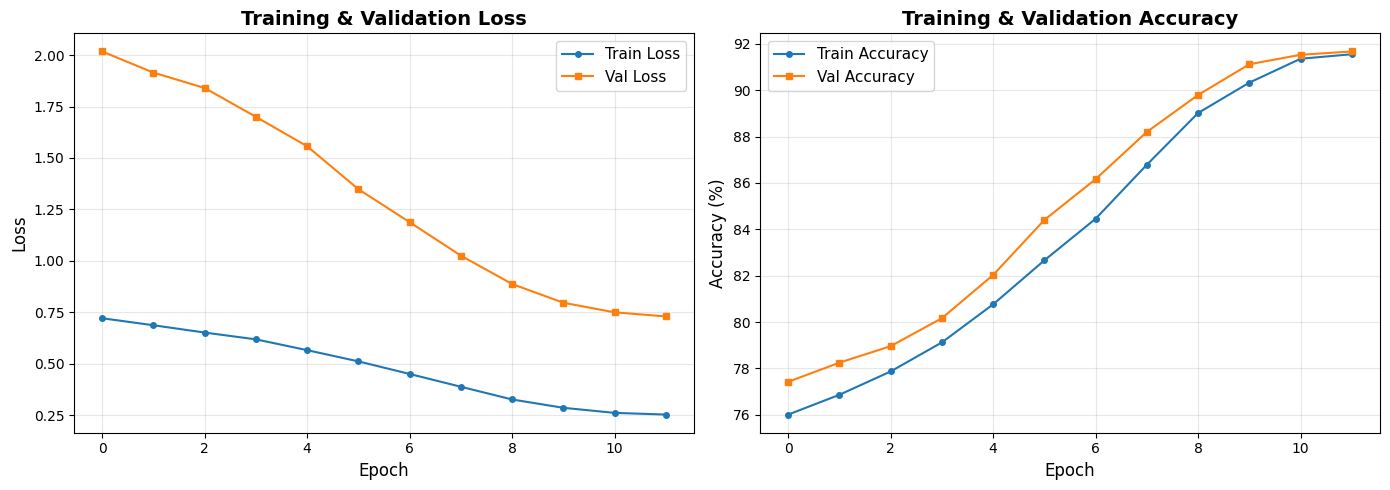

In [ ]:
# Plot Training Results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
train_acc_pct = [acc * 100 for acc in history['train_acc']]
val_acc_pct = [acc * 100 for acc in history['val_acc']]

axes[1].plot(train_acc_pct, label='Train Accuracy', marker='o', markersize=4)
axes[1].plot(val_acc_pct, label='Val Accuracy', marker='s', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs', dpi=300, bbox_inches='tight')
plt.show()



In [24]:
# Testing on Test Set
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Load best model
model = timm.create_model('deit_small_patch16_224', pretrained=False, num_classes=5)
model.load_state_dict(torch.load('SplitDATA/checkpoints/best_model.pth'))
model = model.to(device)
model.eval()

# Test
test_preds = []
test_labels = []

print("Testing on test set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        
        outputs = model(images)
        _, preds = outputs.max(1)
        
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_acc = accuracy_score(test_labels, test_preds)
cm = confusion_matrix(test_labels, test_preds)


print("Test RESULTS: ")

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Class-wise accuracy
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
print("\nClass-wise Accuracy:")
for i in range(5):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"  {class_names[i]:15s}: {class_acc:.2f}%")


# print("CONFUSION MATRIX")

# print(cm)

Testing on test set...


Testing: 100%|██████████| 220/220 [02:22<00:00,  1.54it/s]

Test RESULTS: 

Test Accuracy: 75.62%

Class-wise Accuracy:
  No DR          : 91.69%
  Mild           : 5.71%
  Moderate       : 40.23%
  Severe         : 31.82%
  Proliferative DR: 51.05%


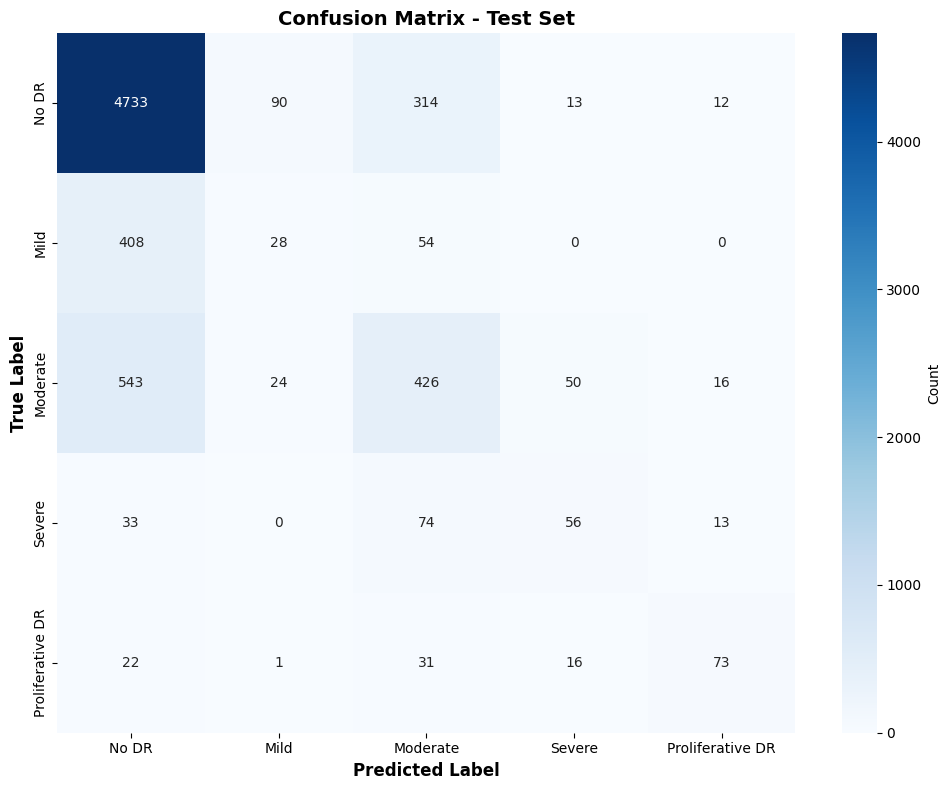

Confusion matrix done!


In [26]:
# Confusion Matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('SplitDATA/logs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix done!")